## Setup

In [1]:
import sys, pathlib
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

sys.path.insert(0, str(pathlib.Path('../src').resolve()))
from lv_geometry import prepare_polar_geometry, project_points_to_polar, polar_mask

pv.set_jupyter_backend('static')

# ── cases: add/remove rows here ───────────────────────────────────────────────
CASES = [
    ('2023', '00016504'),
    ('2024', '50102536'),
    ('2024', '07009967'),
    ('2022', '50002862'),
]

DATASET          = r'F:\RM_TEKNON_DEVELOP'
RESULTS          = pathlib.Path('../results/MartaNunez')   # input: flat VTKs
OUT_DIR          = pathlib.Path('../results/M06')          # output: all saved figures
N_R              = 64
N_THETA          = 128
AHA_DISPLAY_DEG  = 0.0
_DE_MRI_VARIANTS = ('DE-MRI', 'DE-MRI 3D', 'DE-MRI 2D')

# Endo Layer is the mesh flat_LV.py requires (open surface, has base boundary)
# Both methods use Endo Layer points → no mesh bias
_FLAT_NAME = 'Endo Layer_flat_radial_displacement3.0 .vtk'

print(f'{len(CASES)} cases configured')
print(f'Output dir: {OUT_DIR.resolve()}')

4 cases configured
Output dir: C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\lv-scar-segmentation\results\M06


## Helpers

In [2]:
T_pm = np.linspace(0, 2*np.pi, N_THETA+1)
R_pm = np.linspace(0, 1.0,     N_R+1)
T2, R2 = np.meshgrid(T_pm, R_pm)


def _mark_septal_point(ax, theta=np.deg2rad(60), radius=1.04):
    ax.scatter([theta], [radius], s=26, color='dodgerblue', edgecolor='white',
               linewidth=0.7, zorder=10, clip_on=False)


def _draw_bullseye_grid(ax):
    t = np.linspace(0, 2*np.pi, 361)
    for r in (0.25, 0.50, 0.75, 1.0):
        ax.plot(t, np.full_like(t, r), color='#555', lw=0.6, alpha=0.6)
    for deg in (0, 60, 120, 180, 240, 300):
        ax.plot([np.deg2rad(deg)]*2, [0.5, 1.0], color='#555', lw=0.6, alpha=0.6)
    for deg in (45, 135, 225, 315):
        ax.plot([np.deg2rad(deg)]*2, [0.0, 0.5], color='#555', lw=0.6, alpha=0.6)
    ax.set_theta_zero_location('W')
    ax.set_theta_direction(-1)
    ax.set_rticks([])
    ax.set_xticks([])
    _mark_septal_point(ax)


def _load_case(year, pid):
    base    = pathlib.Path(DATASET) / year / pid / 'Basal' / 'Data'
    variant = next((v for v in _DE_MRI_VARIANTS if (base / v / 'LV').is_dir()), None)
    if variant is None:
        return None, 'no DE-MRI folder'
    lv_dir    = base / variant / 'LV'
    rv_path   = base / variant / 'RV' / 'Right Ventricle.vtk'
    endo_path = lv_dir / 'Endo Layer.vtk'
    lv_path   = lv_dir / 'Left Ventricle.vtk'
    core_path = lv_dir / 'TISSUE' / 'Core Surface.vtk'
    bz_path   = lv_dir / 'TISSUE' / 'Border Zone Surface.vtk'
    flat_path = RESULTS / f'{year}_{pid}' / 'Endo Layer_flat_radial_displacement3.0 .vtk'
    for p, label in [(endo_path, 'Endo'), (rv_path, 'RV'), (core_path, 'Core'), (bz_path, 'BZ')]:
        if not p.exists():
            return None, f'{label} missing: {p}'
    if not flat_path.exists():
        cmd = (f'python flat_LV.py'
               f' --lv_meshfile "{endo_path}"'
               f' --rv_meshfile "{rv_path}"'
               f' --outdir "{flat_path.parent}"')
        return None, f'flat VTK missing. Run:\n  {cmd}'
    shell_path = lv_path if lv_path.exists() else endo_path
    return {
        'year': year, 'pid': pid, 'variant': variant,
        'endo':  pv.read(str(endo_path)),
        'shell': pv.read(str(shell_path)),
        'rv':    pv.read(str(rv_path)),
        'core':  pv.read(str(core_path)),
        'bz':    pv.read(str(bz_path)),
        'flat':  pv.read(str(flat_path)),
    }, None


def _scar_mask(endo, core, bz):
    pts     = np.array(endo.points)
    is_scar = np.zeros(len(pts), dtype=bool)
    for mesh in [bz, core]:
        mesh_pts  = np.array(mesh.points)
        self_tree = cKDTree(mesh_pts)
        nn_dist, _ = self_tree.query(mesh_pts, k=2)
        tol       = np.median(nn_dist[:, 1]) * 2.0
        ext_tree  = cKDTree(mesh_pts)
        dist, _   = ext_tree.query(pts, workers=-1)
        is_scar[dist < tol] = True
    return pts, is_scar


print('Helpers ready.')

Helpers ready.


## Per-case: 3D shell + polar comparison

2023/00016504 [DE-MRI 3D]  CZ pts: 12818


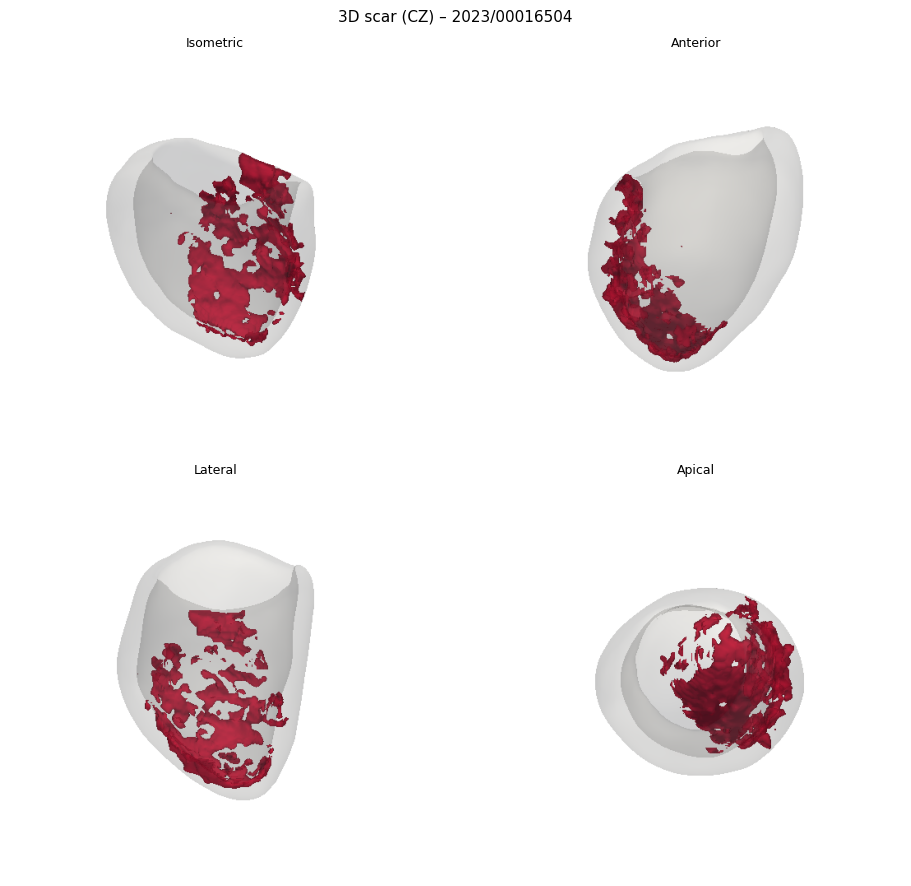

  Saved -> ..\results\M06\M06_3d_scar_2023_00016504.png
  flat scar endo pts: 302/4214  tol=0.61 mm
  flat ref angle: 82.0  handedness: flipped  (d_same=0.191, d_flip=0.990)


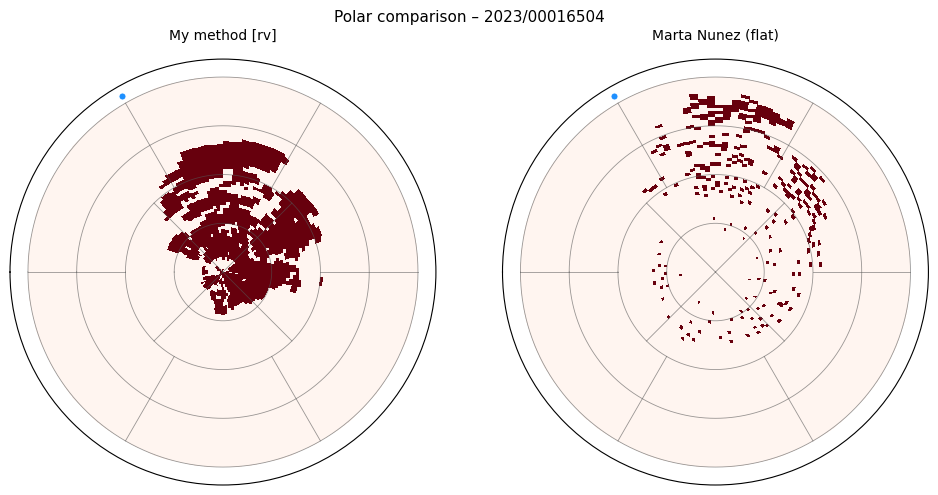

  Saved -> ..\results\M06\M06_polar_comparison_2023_00016504.png
2024/50102536 [DE-MRI 3D]  CZ pts: 1458


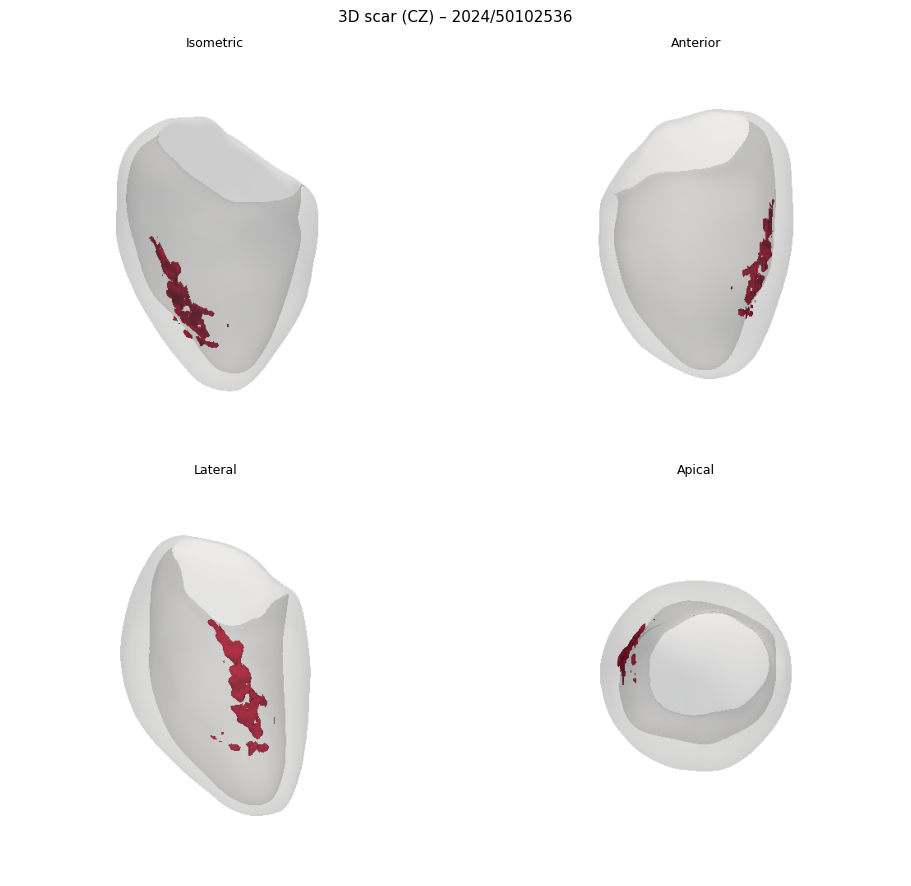

  Saved -> ..\results\M06\M06_3d_scar_2024_50102536.png
  flat scar endo pts: 20/4214  tol=0.52 mm
  flat ref angle: 6.8  handedness: flipped  (d_same=0.071, d_flip=0.984)


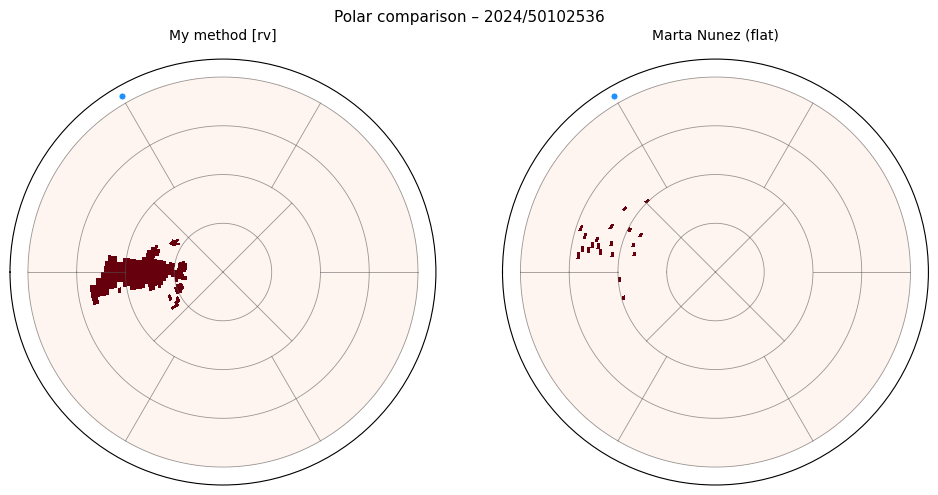

  Saved -> ..\results\M06\M06_polar_comparison_2024_50102536.png
2024/07009967 [DE-MRI 3D]  CZ pts: 824


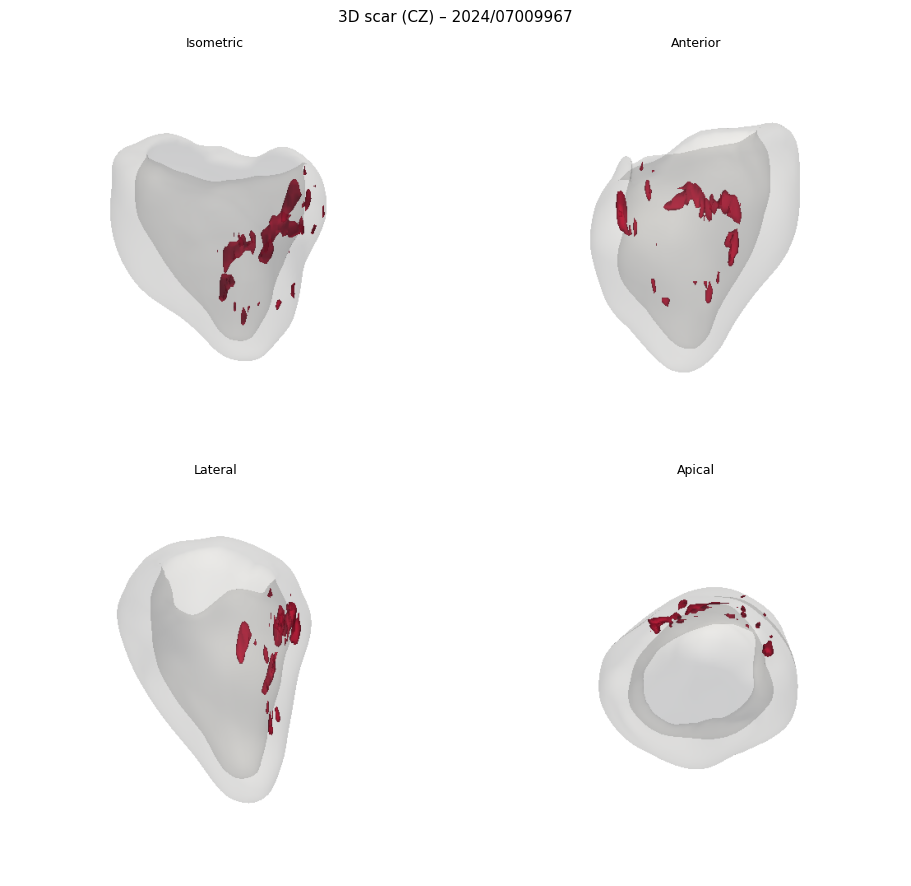

  Saved -> ..\results\M06\M06_3d_scar_2024_07009967.png
  flat scar endo pts: 94/4214  tol=1.15 mm
  flat ref angle: -145.3  handedness: same  (d_same=0.987, d_flip=-0.073)


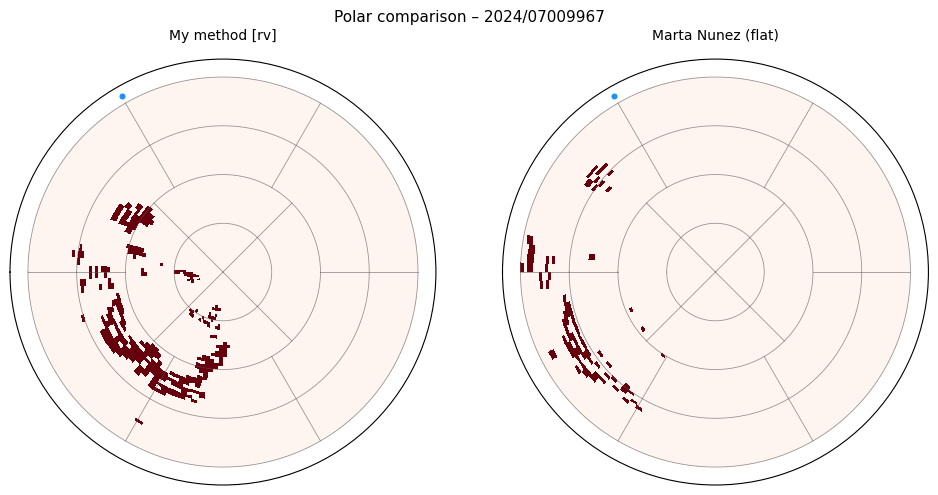

  Saved -> ..\results\M06\M06_polar_comparison_2024_07009967.png
2022/50002862 [DE-MRI 3D]  CZ pts: 134


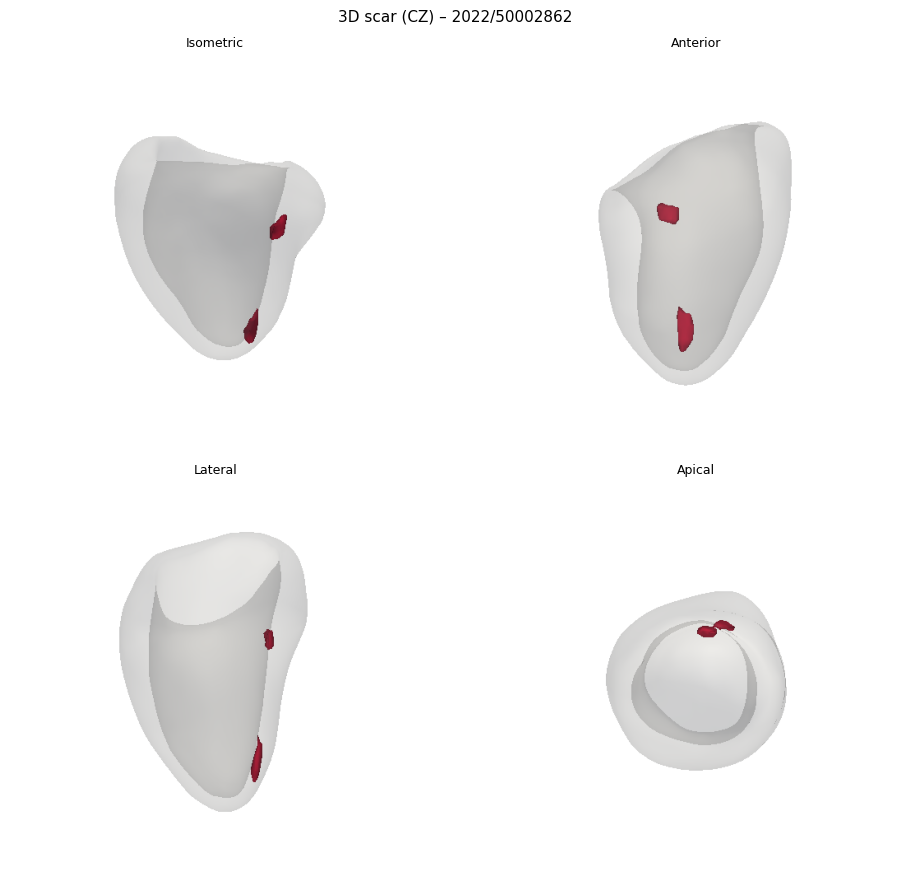

  Saved -> ..\results\M06\M06_3d_scar_2022_50002862.png
  flat scar endo pts: 13/4214  tol=1.23 mm
  flat ref angle: -129.0  handedness: same  (d_same=0.993, d_flip=0.061)


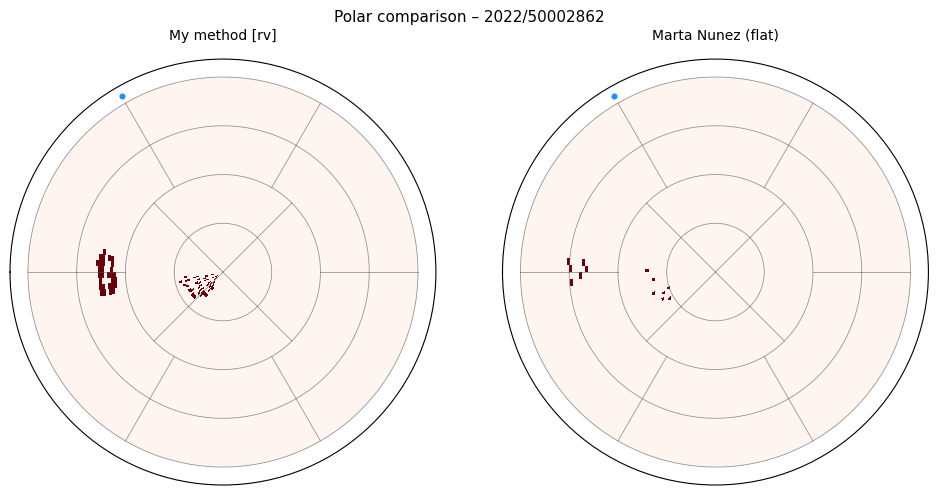

  Saved -> ..\results\M06\M06_polar_comparison_2022_50002862.png


In [3]:
OUT_DIR.mkdir(parents=True, exist_ok=True)

for year, pid in CASES:
    data, err = _load_case(year, pid)
    if data is None:
        print(f'SKIP {year}/{pid}: {err}')
        continue

    endo, shell, rv, core, bz, flat = (
        data['endo'], data['shell'], data['rv'],
        data['core'], data['bz'],   data['flat'])

    cz_pts = np.array(core.points)
    print(f'{year}/{pid} [{data["variant"]}]  CZ pts: {len(cz_pts)}')

    if len(cz_pts) == 0:
        print(f'  SKIP {year}/{pid}: empty CZ mesh')
        continue

    # ── 3D shell: 4 views (CZ only) ──────────────────────────────────────────
    _views = [
        ('Isometric',  'view_isometric'),
        ('Anterior',   'view_xz'),
        ('Lateral',    'view_yz'),
        ('Apical',     'view_xy'),
    ]
    imgs_3d = []
    for _label, _view_fn in _views:
        pl = pv.Plotter(off_screen=True, window_size=(500, 480))
        pl.set_background('white')
        pl.add_mesh(shell, color='#cccccc', opacity=0.15, smooth_shading=True, show_scalar_bar=False)
        pl.add_mesh(core,  color='crimson', opacity=0.95, smooth_shading=True, show_scalar_bar=False)
        try:
            if _view_fn == 'view_xy':
                try:
                    pl.view_xy(negative=True)
                except TypeError:
                    pl.view_xy(); pl.camera.azimuth += 180
            else:
                getattr(pl, _view_fn)()
        except AttributeError:
            pl.view_isometric()  # fallback
        imgs_3d.append((_label, pl.screenshot(None, return_img=True)))
        pl.close()

    fig3d, axes3d = plt.subplots(2, 2, figsize=(10, 9))
    fig3d.suptitle(f'3D scar (CZ) – {year}/{pid}', fontsize=11)
    for ax, (_label, img) in zip(axes3d.ravel(), imgs_3d):
        ax.imshow(img)
        ax.set_title(_label, fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    out3d = OUT_DIR / f'M06_3d_scar_{year}_{pid}.png'
    plt.savefig(out3d, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved -> {out3d}')

    # ── my method: project CZ pts directly via lv_geometry ───────────────────
    geom           = prepare_polar_geometry(endo, rv_mesh=rv)
    theta_cz, s_cz = project_points_to_polar(cz_pts, geom)
    theta_cz_cw    = (2.0*np.pi - theta_cz) % (2.0*np.pi)
    scar_pm        = polar_mask(theta_cz_cw, s_cz, N_R, N_THETA, AHA_DISPLAY_DEG).astype(float)

    # ── flat method: proximity core->endo in 3D, then use flat 2D coords ─────
    endo_pts = np.array(endo.points)
    pts2d    = np.array(flat.points)      # z=0, point[i] == endo_pts[i]
    x_f, y_f = pts2d[:, 0], pts2d[:, 1]

    # tol from core mesh internal spacing (guard: single-point CZ)
    _core_tree = cKDTree(cz_pts)
    if len(cz_pts) >= 2:
        _nn, _ = _core_tree.query(cz_pts, k=2)
        _tol   = np.median(_nn[:, 1]) * 2.0
    else:
        _tol = 5.0  # fallback 5 mm when only 1 CZ point
    _dist, _ = _core_tree.query(endo_pts)
    is_scar  = _dist < _tol
    print(f'  flat scar endo pts: {is_scar.sum()}/{len(endo_pts)}  tol={_tol:.2f} mm')

    # RV ref angle: endo point closest to theta=0 in basal band
    theta_endo, s_endo = project_points_to_polar(endo_pts, geom)
    theta_endo_cw = (2.0*np.pi - theta_endo) % (2.0*np.pi)
    basal_mask    = (s_endo >= 0.6) & (s_endo <= 0.85)

    if basal_mask.sum() == 0:
        print('  WARNING: no basal endo points found; using full endo for RV ref')
        basal_mask = np.ones(len(endo_pts), dtype=bool)

    circ_dist = np.abs(((theta_endo_cw + np.pi) % (2.0*np.pi)) - np.pi)
    circ_dist[~basal_mask] = np.inf
    rv_endo_idx = int(np.argmin(circ_dist))
    ref_angle   = np.arctan2(y_f[rv_endo_idx], x_f[rv_endo_idx])

    theta_flat_raw  = (np.arctan2(y_f, x_f) - ref_angle) % (2.0*np.pi)
    theta_flat_flip = (2.0*np.pi - theta_flat_raw) % (2.0*np.pi)
    bp = basal_mask
    if bp.sum() > 0:
        d_same = np.mean(np.cos(theta_flat_raw[bp]  - theta_endo_cw[bp]))
        d_flip = np.mean(np.cos(theta_flat_flip[bp] - theta_endo_cw[bp]))
        theta_flat_cw = theta_flat_raw if d_same >= d_flip else theta_flat_flip
        hand = 'same' if d_same >= d_flip else 'flipped'
    else:
        d_same, d_flip = float('nan'), float('nan')
        theta_flat_cw = theta_flat_raw
        hand = 'same (no basal pts)'
    print(f'  flat ref angle: {np.rad2deg(ref_angle):.1f}  handedness: {hand}'
          f'  (d_same={d_same:.3f}, d_flip={d_flip:.3f})')

    r_flat    = np.sqrt(x_f**2 + y_f**2)
    r_norm    = r_flat / (r_flat.max() + 1e-9)
    scar_pm_f = polar_mask(theta_flat_cw[is_scar], r_norm[is_scar], N_R, N_THETA, AHA_DISPLAY_DEG).astype(float)

    # ── plot ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), subplot_kw=dict(projection='polar'))
    for ax, pm, title in zip(axes,
            [scar_pm, scar_pm_f],
            ['My method [rv]', 'Marta Nunez (flat)']):
        ax.pcolormesh(T2, R2, pm, cmap='Reds', vmin=0, vmax=1, shading='flat')
        _draw_bullseye_grid(ax)
        ax.set_title(title, pad=14, fontsize=10)
    plt.suptitle(f'Polar comparison – {year}/{pid}', fontsize=11)
    plt.tight_layout()
    out = OUT_DIR / f'M06_polar_comparison_{year}_{pid}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved -> {out}')
